### Medidas Campos Eléctricos y Magnéticos Slayer Exciter

#### Campo Eléctrico

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_Elec = pd.read_excel('CampoElectricoMV.ods', engine='odf')
df_Elec['Tiempo'] = df_Elec.index # A cada fila se le asocia un segundo de tiempo

print(df_Elec.head())


     0cm     5cm    10cm   15cm   20cm   25cm   30cm  Tiempo
0  151.9   -32.0   -52.3   80.2  121.5  160.3  281.3       0
1  152.9   -30.6   -50.8   80.8  121.7  160.3  280.0       1
2  155.4   -30.1   -50.8  306.9  122.0  160.3  205.1       2
3  153.3   -30.1  9240.0  298.1  452.1  160.3  324.6       3
4  153.3  6110.0  9640.0  322.3  489.3  495.4  351.7       4


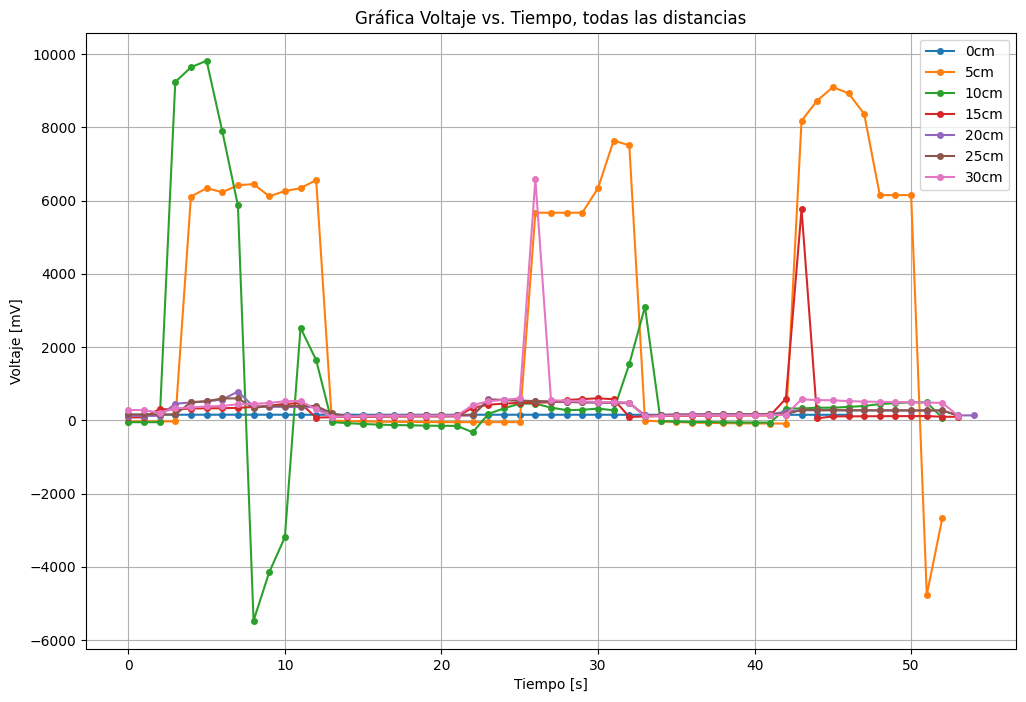

In [2]:
plt.figure(figsize=(12, 8))

# Grafica cada columna (excepto la columna 'Tiempo')
for columna in df_Elec.columns[:-1]:
    plt.plot(df_Elec['Tiempo'], df_Elec[columna], marker='o', markersize="4", label=columna)

# Configura título y etiquetas
plt.title('Gráfica Voltaje vs. Tiempo, todas las distancias')
plt.xlabel('Tiempo [s]')
plt.ylabel('Voltaje [mV]')
plt.legend(loc='upper right')
plt.grid(True)

# Muestra la gráfica
plt.show()

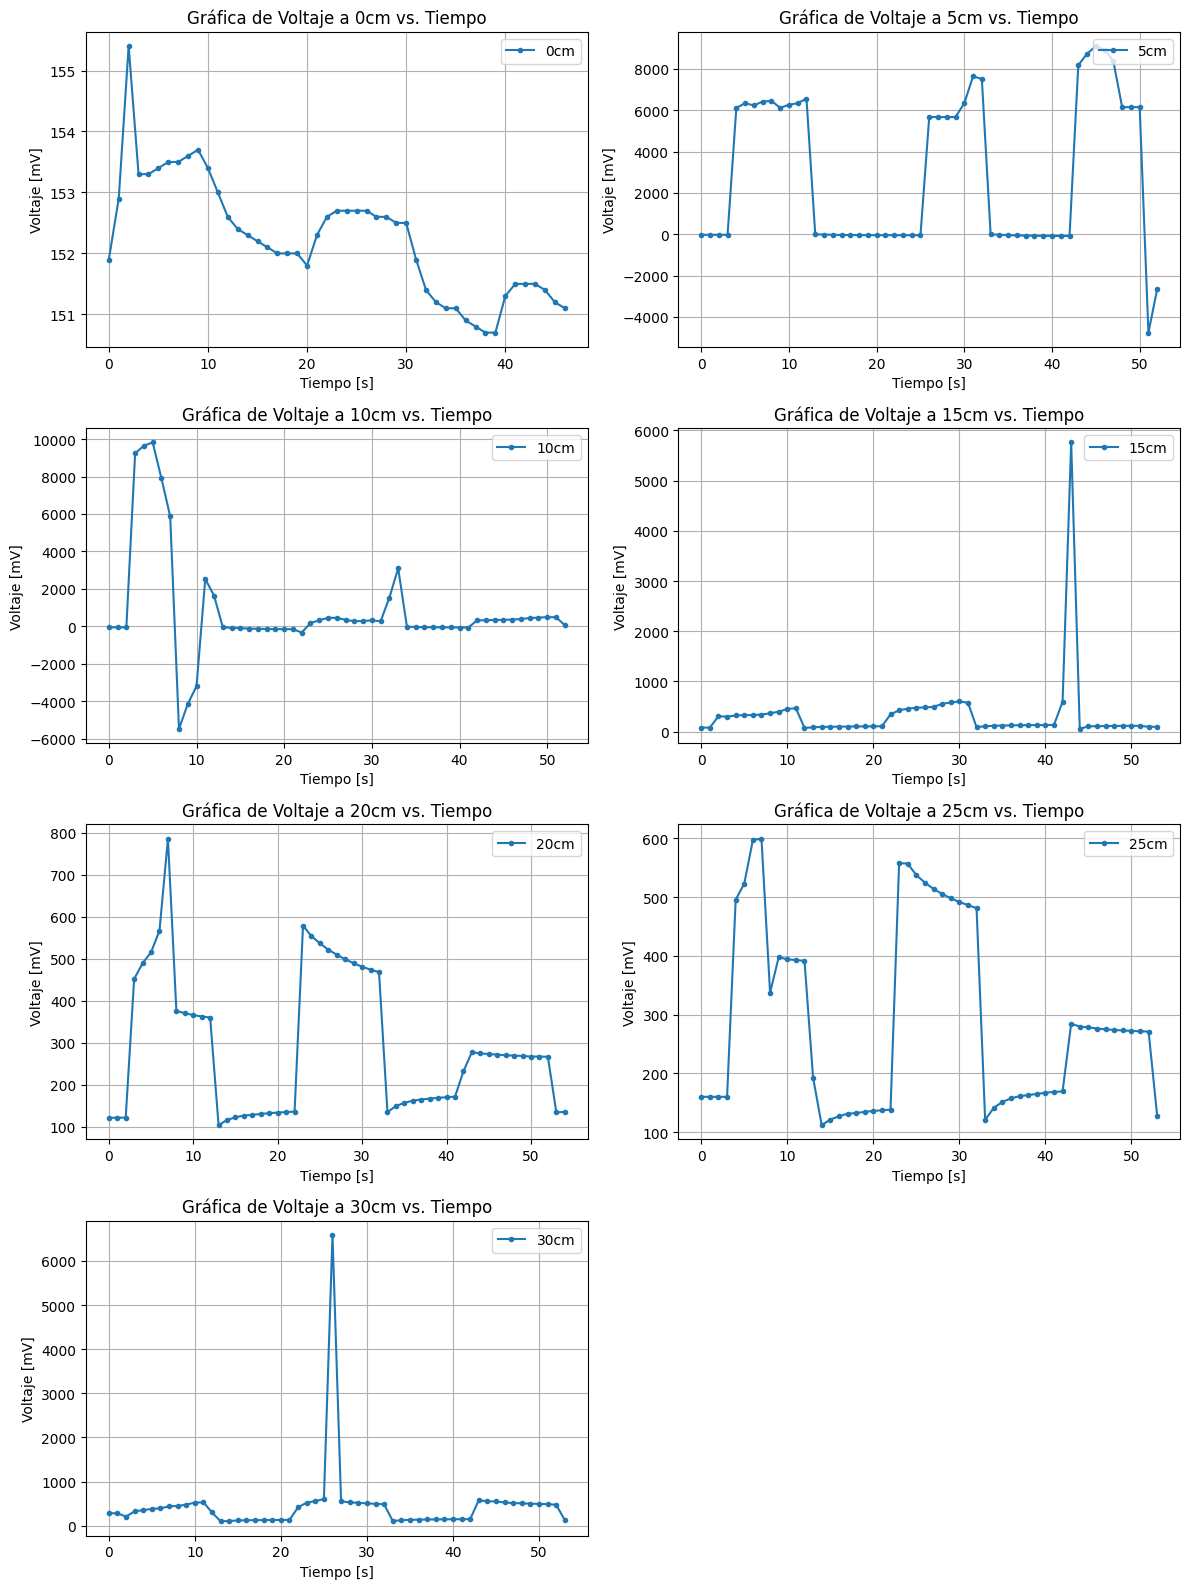

In [3]:

# Crear una figura con 7 subgráficas en 2 columnas
fig, axs = plt.subplots(4, 2, figsize=(12, 16))  # 4 filas, 2 columnas

# Aplanar la matriz de ejes para facilitar la iteración
axs = axs.flatten()

# Grafica cada columna (excepto la columna 'Tiempo')
for i, columna in enumerate(df_Elec.columns[:-1]):
    axs[i].plot(df_Elec['Tiempo'], df_Elec[columna], marker='o', markersize=3, label=columna)
    axs[i].set_title(f'Gráfica de Voltaje a {columna} vs. Tiempo')
    axs[i].set_xlabel('Tiempo [s]')
    axs[i].set_ylabel('Voltaje [mV]')
    axs[i].legend(loc='upper right')
    axs[i].grid(True)

# Eliminar subgráficas vacías si hay menos de 8
for i in range(len(df_Elec.columns) - 1, len(axs)):
    fig.delaxes(axs[i])

# Ajustar el espacio entre subgráficas
fig.tight_layout()

# Muestra la figura
plt.show()


Para hallar los valores de campo eléctrico usaremos la ecuación:

$$ V = \frac{K \cdot q}{r} $$

$$ E = \frac{V}{d} $$

Pero inicialmente es necesario calcular el error propio del multímetro para las diferencias de voltaje:

- 0mV a 60mV  --> $\pm (1.2\% + 5*0.01)$
- 60 mV a 600mV --> $\pm (1.2\% + 5*0.1)$
- 600mV a 6000mV --> $\pm (1.0\% + 3*1)$
- 6000mV a 60000mV --> $\pm (1.0\% + 3*10)$

In [4]:
import pandas as pd

def calcular_error(df):
    # Crear una copia del DataFrame para no modificar el original
    df_copy = df.copy()
    
    for column in df.columns:
        if columna != 'Tiempo':
            if df[column].dtype in [int, float]:  # Asegurarse de que la columna contenga datos numéricos
                error_column = 'e_' + column
                df_copy[error_column] = df[column].apply(calcular_valor_error)
                # Reorganizar las columnas para que la columna de error quede a la derecha de la columna original
                cols = df_copy.columns.tolist()
                col_idx = cols.index(column)
                cols.insert(col_idx + 1, cols.pop(cols.index(error_column)))
                df_copy = df_copy[cols]

    return df_copy

def calcular_valor_error(value):
    value = abs(value)
    if 0 <= value <= 60:
        error = value * 0.012 + 5 * 0.01
    elif 60 < value <= 600:
        error = value * 0.012 + 5 * 0.1
    elif 600 < value <= 6000:
        error = value * 0.01 + 3 * 1
    elif 6000 < value <= 60000:
        error = value * 0.01 + 3 * 10
    else:
        error = 0  # Asumimos que fuera de los rangos dados no hay error
    return error

# Ejemplo de uso
data = {
    'col1': [50, 500, 5500, 70000],
    'col2': [70, 700, 7000, 80000]
}
df = pd.DataFrame(data)
df_con_errores = calcular_error(df)
print(df_con_errores)


    col1  e_col1   col2  e_col2
0     50    0.65     70    1.34
1    500    6.50    700   10.00
2   5500   58.00   7000  100.00
3  70000    0.00  80000    0.00


     0cm   e_0cm     5cm  e_5cm    10cm  e_10cm   15cm  e_15cm   20cm  e_20cm  \
0  151.9  2.3228   -32.0    0.0   -52.3     0.0   80.2  1.4624  121.5  1.9580   
1  152.9  2.3348   -30.6    0.0   -50.8     0.0   80.8  1.4696  121.7  1.9604   
2  155.4  2.3648   -30.1    0.0   -50.8     0.0  306.9  4.1828  122.0  1.9640   
3  153.3  2.3396   -30.1    0.0  9240.0   122.4  298.1  4.0772  452.1  5.9252   
4  153.3  2.3396  6110.0   91.1  9640.0   126.4  322.3  4.3676  489.3  6.3716   

    25cm  e_25cm   30cm  e_30cm  Tiempo  e_Tiempo  
0  160.3  2.4236  281.3  3.8756       0     0.050  
1  160.3  2.4236  280.0  3.8600       1     0.062  
2  160.3  2.4236  205.1  2.9612       2     0.074  
3  160.3  2.4236  324.6  4.3952       3     0.086  
4  495.4  6.4448  351.7  4.7204       4     0.098  


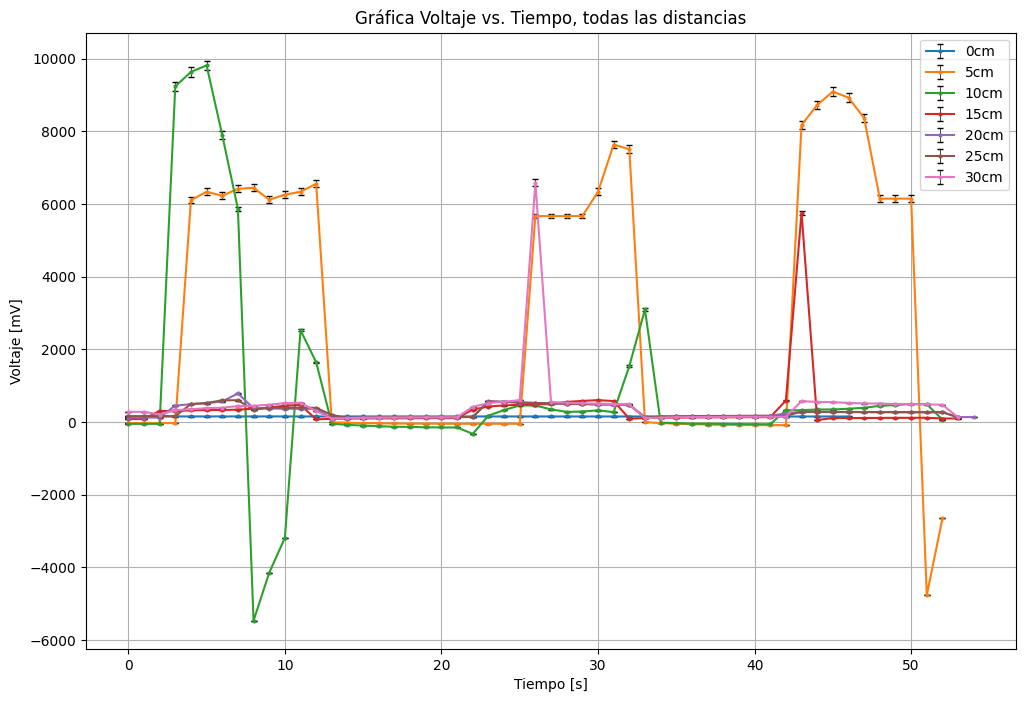

In [6]:
df_Elec = pd.read_excel('CampoElectricoMV.ods', engine='odf')
df_Elec['Tiempo'] = df_Elec.index  # A cada fila se le asocia un segundo de tiempo

# Calcular errores
def calcular_error(df):
    # Crear una copia del DataFrame para no modificar el original
    df_copy = df.copy()
    
    for column in df.columns:
        if df[column].dtype in [int, float]:  # Asegurarse de que la columna contenga datos numéricos
            error_column = 'e_' + column
            df_copy[error_column] = df[column].apply(calcular_valor_error)
            # Reorganizar las columnas para que la columna de error quede a la derecha de la columna original
            cols = df_copy.columns.tolist()
            col_idx = cols.index(column)
            cols.insert(col_idx + 1, cols.pop(cols.index(error_column)))
            df_copy = df_copy[cols]

    return df_copy

def calcular_valor_error(value):
    if 0 <= value <= 60:
        error = value * 0.012 + 5 * 0.01
    elif 60 < value <= 600:
        error = value * 0.012 + 5 * 0.1
    elif 600 < value <= 6000:
        error = value * 0.01 + 3 * 1
    elif 6000 < value <= 60000:
        error = value * 0.01 + 3 * 10
    else:
        error = 0  # Asumimos que fuera de los rangos dados no hay error
    return error

# Calcular errores y agregar las columnas de error al DataFrame
df_Elec = calcular_error(df_Elec)

print(df_Elec.head())

# Crear la gráfica con barras de error
plt.figure(figsize=(12, 8))

# Grafica cada columna (excepto la columna 'Tiempo' y las de error)
for columna in df_Elec.columns:
    if columna != 'Tiempo' and not columna.startswith('e_'):
        error_column = 'e_' + columna
        if error_column in df_Elec.columns:
            plt.errorbar(df_Elec['Tiempo'], df_Elec[columna], yerr=df_Elec[error_column], fmt='-o', markersize=2, label=columna, ecolor='black', capsize=2, elinewidth=0.5)
        else:
            plt.plot(df_Elec['Tiempo'], df_Elec[columna], marker='o', markersize=4, label=columna)

# Configura título y etiquetas
plt.title('Gráfica Voltaje vs. Tiempo, todas las distancias')
plt.xlabel('Tiempo [s]')
plt.ylabel('Voltaje [mV]')
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig('grafica_voltaje_vs_tiempo.jpg', dpi=400)
# Muestra la gráfica
plt.show()

El campo eléctrico está dado por:

$$ E = \frac{V}{d} $$

Al aplicar propagación del error tenemos que:

$$ \Delta E = \frac{V}{d} \sqrt{\left(\frac{\Delta V}{V}\right)^2 + \left(\frac{\Delta d}{d}\right)^2} $$


In [21]:
import pandas as pd
import numpy as np

df_EyDeltaE = pd.DataFrame()
df_EyDeltaE['Tiempo'] = df_EyDeltaE.index
# Definir el error en la distancia
error_d = 0.5

# Calcular los valores de E y Delta E
for i in range(0, 31, 5):
    if i == 0:
        continue
    V_col = f'{i}cm'
    e_V_col = f'e_{i}cm'
    d = i
    df_EyDeltaE[f'E_{i}cm'] = df_Elec[V_col] / d
    df_EyDeltaE[f'Delta_E_{i}cm'] = np.abs(df_EyDeltaE[f'E_{i}cm']) * np.sqrt((df_Elec[e_V_col] / df_Elec[V_col])**2 + (error_d / d)**2)

# Eliminar la columna 'e_Tiempo' del nuevo DataFrame (si existiera)
df_EyDeltaE.drop(columns=['e_Tiempo'], errors='ignore', inplace=True)

# Mostrar el DataFrame resultante
df_EyDeltaE


,Tiempo,E_5cm,Delta_E_5cm,E_10cm,Delta_E_10cm,E_15cm,Delta_E_15cm,E_20cm,Delta_E_20cm,E_25cm,Delta_E_25cm,E_30cm,Delta_E_30cm
0,NaN,-6.40,0.640000,-5.23,0.261500,5.346667,0.203146,6.075,0.180694,6.412,0.160760,9.376667,0.202761
1,NaN,-6.12,0.612000,-5.08,0.254000,5.386667,0.204546,6.085,0.180969,6.412,0.160760,9.333333,0.201873
2,NaN,-6.02,0.602000,-5.08,0.254000,20.460000,0.736806,6.100,0.181382,6.412,0.160760,6.836667,0.150753
3,NaN,-6.02,0.602000,924.00,47.793908,19.873333,0.716041,22.605,0.638072,6.412,0.160760,10.820000,0.232345
4,NaN,1222.00,123.550833,964.00,49.829806,21.486667,0.773147,24.465,0.689622,19.816,0.472786,11.723333,0.250868
5,NaN,1268.00,128.168570,982.00,50.746058,21.940000,0.789194,25.780,0.726069,20.924,0.498612,12.640000,0.269668
6,NaN,1246.00,125.960040,790.00,40.976335,21.980000,0.790610,28.345,0.797168,23.884,0.567615,13.130000,0.279719
7,NaN,1284.00,129.774827,587.00,29.991522,22.713333,0.816571,39.300,1.122566,23.976,0.569760,14.586667,0.309604
8,NaN,1290.00,130.377184,-547.20,27.360000,24.373333,0.875340,18.815,0.533051,13.492,0.325427,14.840000,0.314802
9,NaN,1224.00,123.751596,-415.00,20.750000,26.480000,0.949930,18.515,0.524739,15.908,0.381711,15.840000,0.335321


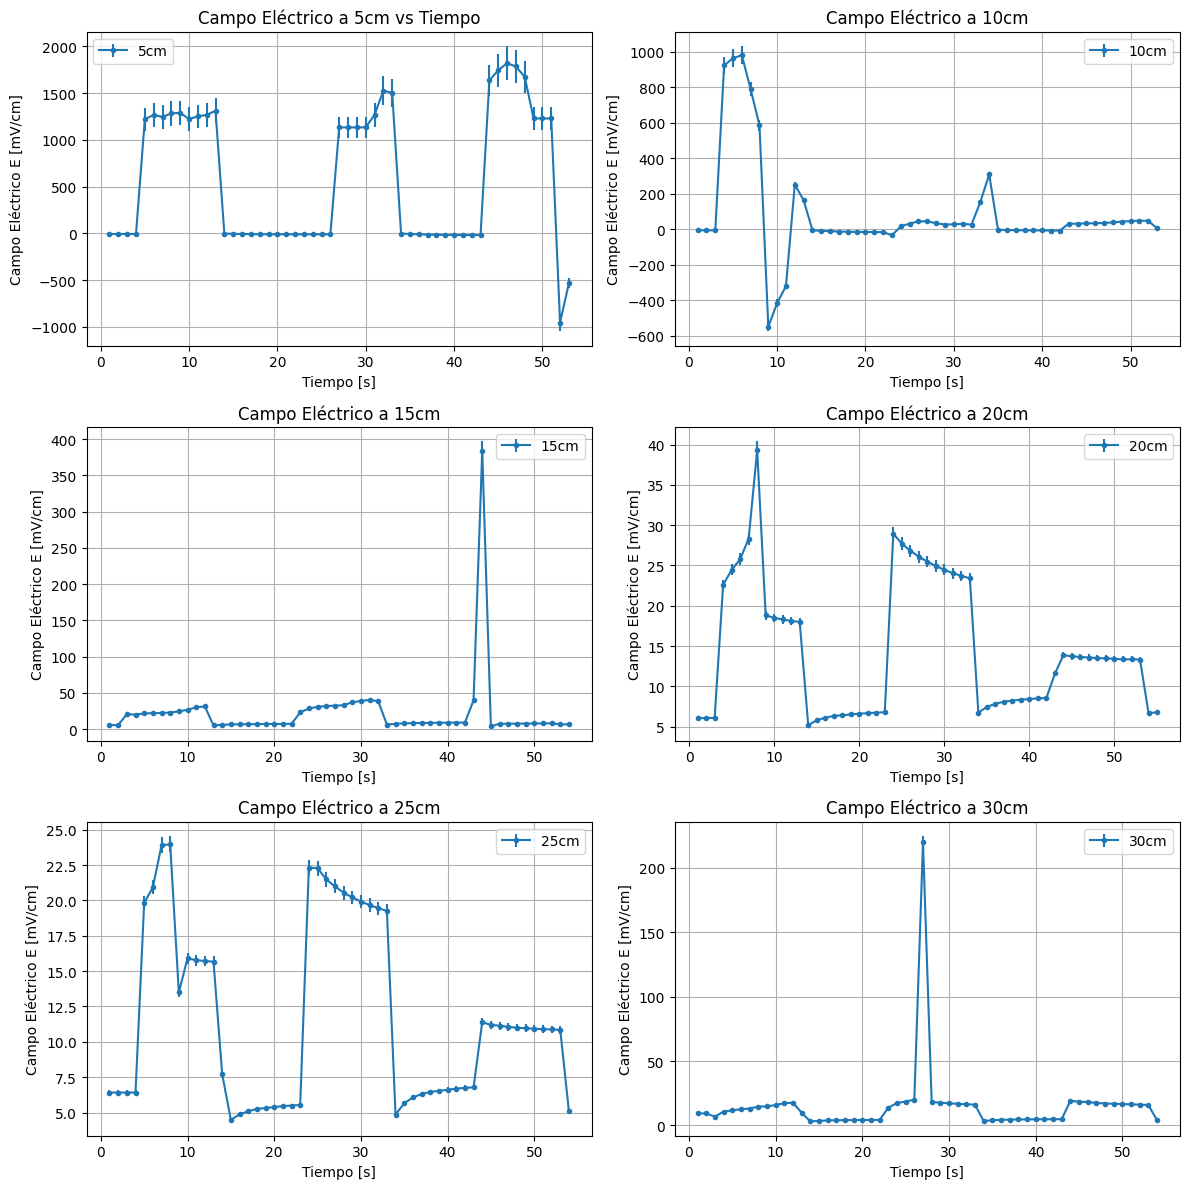

In [29]:
df_EyDeltaE['Tiempo'] = df_EyDeltaE.index + 1

# Identificar las columnas que queremos graficar
distances = [5, 10, 15, 20, 25, 30]

# Número de columnas para las subgráficas (puedes ajustar este valor)
num_cols = 2

# Calcular el número de filas necesarias para acomodar todas las series de datos
num_rows = 3

# Crear la figura con el número calculado de subgráficas
fig, axs = plt.subplots(num_rows, num_cols, figsize=(12, 4 * num_rows))

# Aplanar la matriz de ejes para facilitar la iteración
axs = axs.flatten()

# Graficar cada columna de campo eléctrico con su error en subgráficas separadas

axs[0].errorbar(df_EyDeltaE['Tiempo'], df_EyDeltaE['E_5cm'], yerr=df_EyDeltaE['Delta_E_5cm'], fmt='-o', markersize='3', label='5cm')
axs[0].set_title(f'Campo Eléctrico a 5cm vs Tiempo')
axs[0].set_xlabel('Tiempo [s]')
axs[0].set_ylabel('Campo Eléctrico E [mV/cm]')
axs[0].legend()
axs[0].grid(True)

axs[1].errorbar(df_EyDeltaE['Tiempo'], df_EyDeltaE['E_10cm'], yerr=df_EyDeltaE['Delta_E_10cm'], fmt='-o', markersize='3', label='10cm')
axs[1].set_title(f'Campo Eléctrico a 10cm')
axs[1].set_xlabel('Tiempo [s]')
axs[1].set_ylabel('Campo Eléctrico E [mV/cm]')
axs[1].legend()
axs[1].grid(True)

axs[2].errorbar(df_EyDeltaE['Tiempo'], df_EyDeltaE['E_15cm'], yerr=df_EyDeltaE['Delta_E_15cm'], fmt='-o', markersize='3', label='15cm')
axs[2].set_title(f'Campo Eléctrico a 15cm')
axs[2].set_xlabel('Tiempo [s]')
axs[2].set_ylabel('Campo Eléctrico E [mV/cm]')
axs[2].legend()
axs[2].grid(True)

axs[3].errorbar(df_EyDeltaE['Tiempo'], df_EyDeltaE['E_20cm'], yerr=df_EyDeltaE['Delta_E_20cm'], fmt='-o', markersize='3', label='20cm')
axs[3].set_title(f'Campo Eléctrico a 20cm')
axs[3].set_xlabel('Tiempo [s]')
axs[3].set_ylabel('Campo Eléctrico E [mV/cm]')
axs[3].legend()
axs[3].grid(True)

axs[4].errorbar(df_EyDeltaE['Tiempo'], df_EyDeltaE['E_25cm'], yerr=df_EyDeltaE['Delta_E_25cm'], fmt='-o', markersize='3', label='25cm')
axs[4].set_title(f'Campo Eléctrico a 25cm')
axs[4].set_xlabel('Tiempo [s]')
axs[4].set_ylabel('Campo Eléctrico E [mV/cm]')
axs[4].legend()
axs[4].grid(True)

axs[5].errorbar(df_EyDeltaE['Tiempo'], df_EyDeltaE['E_30cm'], yerr=df_EyDeltaE['Delta_E_30cm'], fmt='-o', markersize='3', label='30cm')
axs[5].set_title(f'Campo Eléctrico a 30cm')
axs[5].set_xlabel('Tiempo [s]')
axs[5].set_ylabel('Campo Eléctrico E [mV/cm]')
axs[5].legend()
axs[5].grid(True)


# Ajustar el espacio entre subgráficas
fig.tight_layout()
plt.savefig('CamposElectricos por distancia vs Tiempo.jpg', dpi=400)
# Mostrar la figura
plt.show()

#### Valores de E a 5cm

In [53]:
E_5cm = df_EyDeltaE['E_5cm'].to_numpy()
DE_5cm = df_EyDeltaE['Delta_E_5cm'].to_numpy()
print(E_5cm, DE_5cm)

[-6.400e+00 -6.120e+00 -6.020e+00 -6.020e+00  1.222e+03  1.268e+03
  1.246e+03  1.284e+03  1.290e+03  1.224e+03  1.252e+03  1.268e+03
  1.312e+03 -1.540e+00 -4.020e+00 -5.820e+00 -7.280e+00 -8.220e+00
 -8.940e+00 -9.240e+00 -9.560e+00 -9.740e+00 -9.800e+00 -9.800e+00
 -9.800e+00 -9.800e+00  1.134e+03  1.134e+03  1.134e+03  1.134e+03
  1.268e+03  1.528e+03  1.502e+03 -1.260e+00 -5.840e+00 -9.460e+00
 -1.196e+01 -1.394e+01 -1.540e+01 -1.646e+01 -1.704e+01 -1.742e+01
 -1.756e+01  1.636e+03  1.746e+03  1.820e+03  1.786e+03  1.674e+03
  1.230e+03  1.230e+03  1.230e+03 -9.530e+02 -5.310e+02        nan
        nan] [6.40000000e-01 6.12000000e-01 6.02000000e-01 6.02000000e-01
 1.23550833e+02 1.28168570e+02 1.25960040e+02 1.29774827e+02
 1.30377184e+02 1.23751596e+02 1.26562358e+02 1.28168570e+02
 1.32585876e+02 1.54000000e-01 4.02000000e-01 5.82000000e-01
 7.28000000e-01 8.22000000e-01 8.94000000e-01 9.24000000e-01
 9.56000000e-01 9.74000000e-01 9.80000000e-01 9.80000000e-01
 9.80000000e-01 9.

In [54]:
E_5cm_c = E_5cm[~np.isnan(E_5cm)]
DE_5cm_c = DE_5cm[~np.isnan(DE_5cm)]
print(E_5cm_c, DE_5cm_c)

[-6.400e+00 -6.120e+00 -6.020e+00 -6.020e+00  1.222e+03  1.268e+03
  1.246e+03  1.284e+03  1.290e+03  1.224e+03  1.252e+03  1.268e+03
  1.312e+03 -1.540e+00 -4.020e+00 -5.820e+00 -7.280e+00 -8.220e+00
 -8.940e+00 -9.240e+00 -9.560e+00 -9.740e+00 -9.800e+00 -9.800e+00
 -9.800e+00 -9.800e+00  1.134e+03  1.134e+03  1.134e+03  1.134e+03
  1.268e+03  1.528e+03  1.502e+03 -1.260e+00 -5.840e+00 -9.460e+00
 -1.196e+01 -1.394e+01 -1.540e+01 -1.646e+01 -1.704e+01 -1.742e+01
 -1.756e+01  1.636e+03  1.746e+03  1.820e+03  1.786e+03  1.674e+03
  1.230e+03  1.230e+03  1.230e+03 -9.530e+02 -5.310e+02] [6.40000000e-01 6.12000000e-01 6.02000000e-01 6.02000000e-01
 1.23550833e+02 1.28168570e+02 1.25960040e+02 1.29774827e+02
 1.30377184e+02 1.23751596e+02 1.26562358e+02 1.28168570e+02
 1.32585876e+02 1.54000000e-01 4.02000000e-01 5.82000000e-01
 7.28000000e-01 8.22000000e-01 8.94000000e-01 9.24000000e-01
 9.56000000e-01 9.74000000e-01 9.80000000e-01 9.80000000e-01
 9.80000000e-01 9.80000000e-01 1.14026855

In [41]:
E_5cm_on = E_5cm_c[(E_5cm_c >= 1000) & (E_5cm_c <= 1500)]
E_5cm_off = E_5cm_c[(E_5cm_c < 1000) & (E_5cm_c > -10)]

print(E_5cm_on, np.mean(E_5cm_on))
print(E_5cm_off, np.mean(E_5cm_off))

[1222. 1268. 1246. 1284. 1290. 1224. 1252. 1268. 1312. 1134. 1134. 1134.
 1134. 1268. 1230. 1230. 1230.] 1227.0588235294117
[-6.4  -6.12 -6.02 -6.02 -1.54 -4.02 -5.82 -7.28 -8.22 -8.94 -9.24 -9.56
 -9.74 -9.8  -9.8  -9.8  -9.8  -1.26 -5.84 -9.46] -7.234


#### Valores a 10 cm

In [48]:
E_10cm = df_EyDeltaE['E_10cm'].to_numpy()
E_10cm_c = E_10cm[~np.isnan(E_10cm)]

print(E_10cm_c)


[  -5.23   -5.08   -5.08  924.    964.    982.    790.    587.   -547.2
 -415.   -319.2   252.7   164.4    -4.78   -7.79   -9.95  -11.7   -12.99
  -13.51  -14.55  -14.99  -15.12  -32.67   17.56   32.78   45.66   45.5
   34.74   27.82   28.78   32.1    27.29  154.    310.     -1.91   -3.05
   -4.75   -4.62   -5.36   -5.76   -6.05   -6.14   32.24   32.42   34.45
   34.53   36.57   39.25   44.42   46.92   49.38   48.85    6.54]


In [49]:
E_10cm_on = E_10cm_c[(E_10cm_c >= 30) & (E_10cm_c <= 1000)]
E_10cm_off = E_10cm_c[(E_10cm_c < 30) & (E_10cm_c > -20)]

print(E_10cm_on, np.mean(E_10cm_on))
print(E_10cm_off, np.mean(E_10cm_off))

[924.   964.   982.   790.   587.   252.7  164.4   32.78  45.66  45.5
  34.74  32.1  154.   310.    32.24  32.42  34.45  34.53  36.57  39.25
  44.42  46.92  49.38  48.85] 238.24625
[ -5.23  -5.08  -5.08  -4.78  -7.79  -9.95 -11.7  -12.99 -13.51 -14.55
 -14.99 -15.12  17.56  27.82  28.78  27.29  -1.91  -3.05  -4.75  -4.62
  -5.36  -5.76  -6.05  -6.14   6.54] -2.0168


#### Valores a 15 cm

In [50]:
E_15cm = df_EyDeltaE['E_15cm'].to_numpy()
E_15cm_c = E_15cm[~np.isnan(E_15cm)]

print(E_15cm_c)

[  5.34666667   5.38666667  20.46        19.87333333  21.48666667
  21.94        21.98        22.71333333  24.37333333  26.48
  30.05333333  31.11333333   4.9          5.79333333   6.23333333
   6.50666667   6.62         6.75333333   6.9          6.96
   7.05333333   7.11333333  22.92        28.39333333  30.5
  31.74666667  32.12        32.87333333  36.86666667  38.7
  40.10666667  38.40666667   6.08         7.14         7.76
   8.10666667   8.3          8.49333333   8.6          8.72
   8.82         8.90666667  39.45333333 384.06666667   3.64666667
   7.19333333   7.18         7.41333333   7.49333333   7.64666667
   7.69333333   7.82         6.42         6.47333333]


In [51]:
E_15cm_on = E_15cm_c[(E_15cm_c >= 20) & (E_15cm_c <= 50)]
E_15cm_off = E_15cm_c[(E_15cm_c < 20) & (E_15cm_c > 0)]

print(E_15cm_on, np.mean(E_15cm_on))
print(E_15cm_off, np.mean(E_15cm_off))

[20.46       21.48666667 21.94       21.98       22.71333333 24.37333333
 26.48       30.05333333 31.11333333 22.92       28.39333333 30.5
 31.74666667 32.12       32.87333333 36.86666667 38.7        40.10666667
 38.40666667 39.45333333] 29.63433333333333
[ 5.34666667  5.38666667 19.87333333  4.9         5.79333333  6.23333333
  6.50666667  6.62        6.75333333  6.9         6.96        7.05333333
  7.11333333  6.08        7.14        7.76        8.10666667  8.3
  8.49333333  8.6         8.72        8.82        8.90666667  3.64666667
  7.19333333  7.18        7.41333333  7.49333333  7.64666667  7.69333333
  7.82        6.42        6.47333333] 7.434747474747474
